<a href="https://colab.research.google.com/github/mahir-rana/Accenture-1D-contract-review-challenge/blob/main/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [256]:
import os
REPO_DIR = "/content/Accenture-1D-contract-review-challenge"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Break-Through-Tech/Accenture-1D-contract-review-challenge/ {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

%cd {REPO_DIR}

Already up to date.
c:\content\Accenture-1D-contract-review-challenge


c:\Users\wanga\Accenture-1D-contract-review-challenge\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [257]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [258]:
root_dir = "." # needs to be changed when working in Colab...

with open(f"{root_dir}/data/cuad/train_separate_questions.json") as f:
  data = json.load(f)

categories_df = pd.read_csv(f"{root_dir}/data/cuad/category_descriptions.csv")

# Stripping prefixes from each entry:
categories_df.rename(columns={"Category (incl. context and answer)": "Category"}, inplace=True)
categories_df = categories_df.apply(lambda col: col.astype(str).str.removeprefix(col.name).str.lstrip(": "))


In [259]:
categories_df.head()

,Category,Description,Answer Format,Group
0,Document Name,The name of the contract,Contract Name,-
1,Parties,The two or more parties who signed the contract,Entity or individual names,-
2,Agreement Date,The date of the contract,Date (mm/dd/yyyy),1
3,Effective Date,The date when the contract is effective,Date (mm/dd/yyyy),1
4,Expiration Date,On what date will the contract's initial term ...,Date (mm/dd/yyyy) / Perpetual,1


## Flattening training json into a DataFrame

In [260]:
# Initial rough pass
df = pd.json_normalize(data["data"], record_path=["paragraphs", "qas"], meta=["title"])

print(df.shape)
df.head()


(22450, 5)


,answers,id,question,is_impossible,title
0,"[{'text': 'DISTRIBUTOR AGREEMENT', 'answer_sta...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...
1,"[{'text': 'Distributor', 'answer_start': 244}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...
2,"[{'text': 'Electric City of Illinois L.L.C.', ...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...
3,"[{'text': 'Electric City of Illinois LLC', 'an...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...
4,"[{'text': 'Company', 'answer_start': 197}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...


## Questions
Exploring the questions column:

In [261]:
df['question'].nunique() 
# 41 unique values

41

In [262]:
# a question looks like this:
df['question'][0]

'Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract'

Add a `category` column to `df`, corresponding to the column in `categories_df`.

In [263]:
df['category'] = df['question'].str.extract(r'"([^"]+)"')

In [264]:
df.head()

,answers,id,question,is_impossible,title,category
0,"[{'text': 'DISTRIBUTOR AGREEMENT', 'answer_sta...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name
1,"[{'text': 'Distributor', 'answer_start': 244}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties
2,"[{'text': 'Electric City of Illinois L.L.C.', ...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties
3,"[{'text': 'Electric City of Illinois LLC', 'an...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties
4,"[{'text': 'Company', 'answer_start': 197}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties


In [265]:
print(df['category'].unique())

['Document Name' 'Parties' 'Agreement Date' 'Effective Date'
 'Expiration Date' 'Renewal Term' 'Notice Period To Terminate Renewal'
 'Governing Law' 'Most Favored Nation' 'Non-Compete' 'Exclusivity'
 'No-Solicit Of Customers' 'Competitive Restriction Exception'
 'No-Solicit Of Employees' 'Non-Disparagement'
 'Termination For Convenience' 'Rofr/Rofo/Rofn' 'Change Of Control'
 'Anti-Assignment' 'Revenue/Profit Sharing' 'Price Restrictions'
 'Minimum Commitment' 'Volume Restriction' 'Ip Ownership Assignment'
 'Joint Ip Ownership' 'License Grant' 'Non-Transferable License'
 'Affiliate License-Licensor' 'Affiliate License-Licensee'
 'Unlimited/All-You-Can-Eat-License' 'Irrevocable Or Perpetual License'
 'Source Code Escrow' 'Post-Termination Services' 'Audit Rights'
 'Uncapped Liability' 'Cap On Liability' 'Liquidated Damages'
 'Warranty Duration' 'Insurance' 'Covenant Not To Sue'
 'Third Party Beneficiary']


Now we can visualize the distribution of question categories:

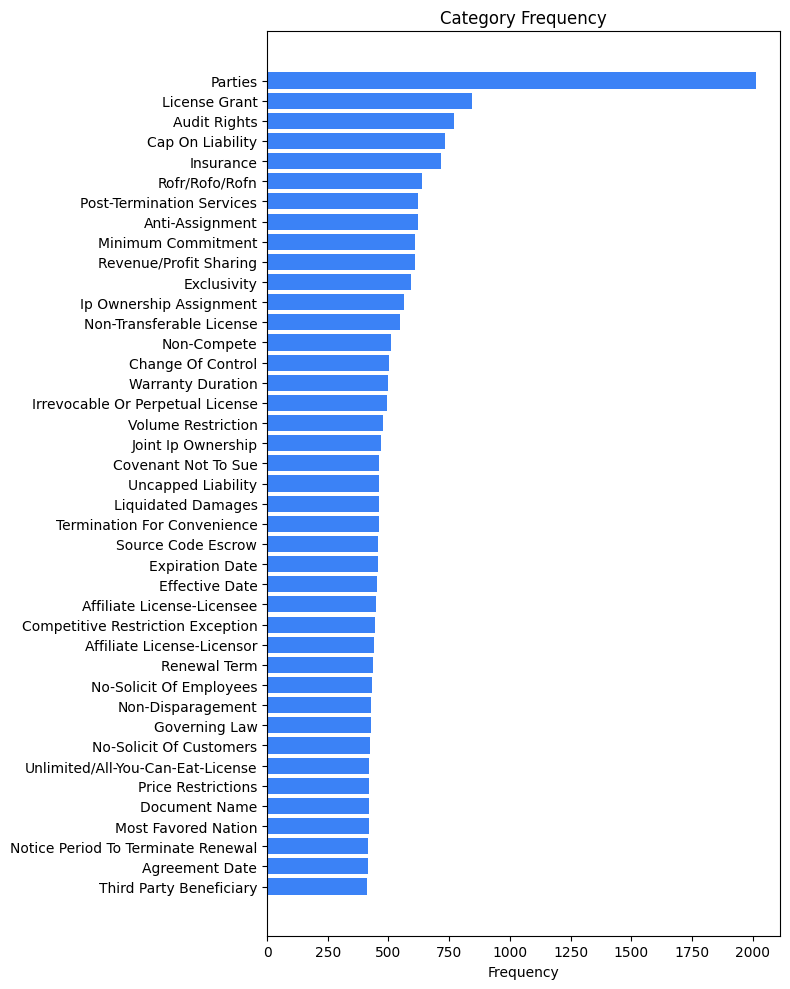

In [266]:
category_counts = df['category'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(category_counts.index, category_counts.values, color='#3b82f6')
ax.set_xlabel('Frequency')
ax.set_title('Category Frequency')
plt.tight_layout()
plt.show()

In [267]:
mode_category = df['category'].value_counts().idxmax()
print(f'The majority of questions are under the category {mode_category}: {df["category"].value_counts().max()} questions')
print(f'Parties description: {categories_df.loc[categories_df["Category"] == mode_category, "Description"].values[0]}')

The majority of questions are under the category Parties: 2012 questions
Parties description: The two or more parties who signed the contract


One-hot-encode the categories:

In [269]:
df = pd.concat([df, pd.get_dummies(df['category'], prefix='category', dtype=int)], axis=1)
df.head()

,answers,id,question,is_impossible,title,category,category_Affiliate License-Licensee,category_Affiliate License-Licensor,category_Agreement Date,category_Anti-Assignment,...,category_Renewal Term,category_Revenue/Profit Sharing,category_Rofr/Rofo/Rofn,category_Source Code Escrow,category_Termination For Convenience,category_Third Party Beneficiary,category_Uncapped Liability,category_Unlimited/All-You-Can-Eat-License,category_Volume Restriction,category_Warranty Duration
0,"[{'text': 'DISTRIBUTOR AGREEMENT', 'answer_sta...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,"[{'text': 'Distributor', 'answer_start': 244}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,"[{'text': 'Electric City of Illinois L.L.C.', ...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,"[{'text': 'Electric City of Illinois LLC', 'an...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,"[{'text': 'Company', 'answer_start': 197}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


This gets a rough extraction. Can we trivialize some keys of the original json? It seems the paragraphs and answers keys are always length <= 1. Confirming:

In [270]:


from collections import Counter

paragraphs_lens = Counter(len(c['paragraphs']) for c in data['data'])
print("paragraphs lengths:", paragraphs_lens)

answers_lens = Counter(
    len(qa['answers'])
    for c in data['data']
    for p in c['paragraphs']
    for qa in p['qas']
)
print("answers lengths:", answers_lens)

paragraphs lengths: Counter({1: 408})
answers lengths: Counter({0: 11270, 1: 11180})


All documents in the training set correspond to exactly one paragraph, so paragraph doesn't need to be a separate column.\
The key answer is either of length 0 or 1. The contents of answer look like:

In [271]:
df['answers'][0]

[{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}]

## Answers
Processing answer-related columns of the dataset.

Split the answer text into columns `answer_text` and `answer_start`:

In [272]:
df['answer_text'] = df['answers'].apply(lambda x: x[0]['text'] if x else None)
df['answer_start'] = df['answers'].apply(lambda x: (x[0]['answer_start']) if x else None)


In [273]:
df.head()

,answers,id,question,is_impossible,title,category,category_Affiliate License-Licensee,category_Affiliate License-Licensor,category_Agreement Date,category_Anti-Assignment,...,category_Rofr/Rofo/Rofn,category_Source Code Escrow,category_Termination For Convenience,category_Third Party Beneficiary,category_Uncapped Liability,category_Unlimited/All-You-Can-Eat-License,category_Volume Restriction,category_Warranty Duration,answer_text,answer_start
0,"[{'text': 'DISTRIBUTOR AGREEMENT', 'answer_sta...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,0,0,0,0,...,0,0,0,0,0,0,0,0,DISTRIBUTOR AGREEMENT,44.0
1,"[{'text': 'Distributor', 'answer_start': 244}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,0,0,0,Distributor,244.0
2,"[{'text': 'Electric City of Illinois L.L.C.', ...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,0,0,0,Electric City of Illinois L.L.C.,49574.0
3,"[{'text': 'Electric City of Illinois LLC', 'an...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,0,0,0,Electric City of Illinois LLC,212.0
4,"[{'text': 'Company', 'answer_start': 197}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,0,0,0,Company,197.0


## Impossibility
Exploring impossibility values:

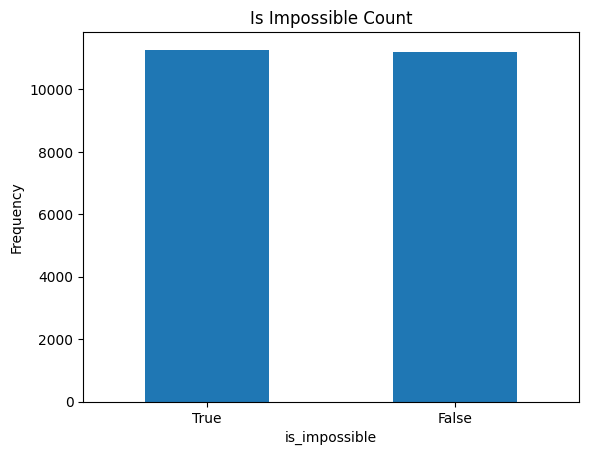

In [274]:
df['is_impossible'].value_counts().plot(kind='bar', rot=0)

plt.title("Is Impossible Count")
plt.ylabel("Frequency")
plt.show()


A fairly even split. Getting exact value counts:

In [275]:
df['is_impossible'].value_counts()

is_impossible
True     11270
False    11180
Name: count, dtype: int64

Binarizing this column:

In [276]:
df['is_impossible_bin'] = df['is_impossible'].apply(lambda x: 1 if x else 0)
df.head()

,answers,id,question,is_impossible,title,category,category_Affiliate License-Licensee,category_Affiliate License-Licensor,category_Agreement Date,category_Anti-Assignment,...,category_Source Code Escrow,category_Termination For Convenience,category_Third Party Beneficiary,category_Uncapped Liability,category_Unlimited/All-You-Can-Eat-License,category_Volume Restriction,category_Warranty Duration,answer_text,answer_start,is_impossible_bin
0,"[{'text': 'DISTRIBUTOR AGREEMENT', 'answer_sta...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,0,0,0,0,...,0,0,0,0,0,0,0,DISTRIBUTOR AGREEMENT,44.0,0
1,"[{'text': 'Distributor', 'answer_start': 244}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,0,0,Distributor,244.0,0
2,"[{'text': 'Electric City of Illinois L.L.C.', ...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,0,0,Electric City of Illinois L.L.C.,49574.0,0
3,"[{'text': 'Electric City of Illinois LLC', 'an...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,0,0,Electric City of Illinois LLC,212.0,0
4,"[{'text': 'Company', 'answer_start': 197}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,0,0,Company,197.0,0


## Explore Correlations
Are certain categories in the dataset more likely to be impossible to answer? More generally, how is impossibility correlated to other features?


Extract features for the correlation map:

In [277]:
print(df['title'].nunique())
print(df['title'].unique())

408
['LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT'
 'WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION AND DISTRIBUTION AGREEMENT'
 'NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEMENT'
 'ADAMSGOLFINC_03_21_2005-EX-10.17-ENDORSEMENT AGREEMENT'
 'KIROMICBIOPHARMA,INC_05_11_2020-EX-10.23-CONSULTING AGREEMENT'
 'VEONEER,INC_02_21_2020-EX-10.11-JOINT VENTURE AGREEMENT'
 'MetLife, Inc. - Remarketing Agreement'
 'FTENETWORKS,INC_02_18_2016-EX-99.4-STRATEGIC ALLIANCE AGREEMENT'
 'DOMINIADVISORTRUST_02_18_2005-EX-99.(H)(2)-SPONSORSHIP AGREEMENT'
 'PfHospitalityGroupInc_20150923_10-12G_EX-10.1_9266710_EX-10.1_Franchise Agreement3'
 'CerenceInc_20191002_8-K_EX-10.4_11827494_EX-10.4_Intellectual Property Agreement'
 'ReynoldsConsumerProductsInc_20191115_S-1_EX-10.18_11896469_EX-10.18_Supply Agreement'
 'IntegrityFunds_20200121_485BPOS_EX-99.E UNDR CONTR_11948727_EX-99.E UNDR CONTR_Service Agreement'
 'PREMIERBIOMEDICALINC_05_14_2020-EX-10.2-INTELLECTUAL PROPERTY AGREEMENT'
 'SIBANNAC,INC_12_04_20

In [ ]:
# how many unique titles (contracts) and categories
print(df['title'].nunique(), 'unique titles')
print(df['category'].nunique(), 'unique categories')




408 unique titles
41 unique categories
count    408.00000
mean      55.02451
std       13.44072
min       41.00000
25%       46.00000
50%       50.00000
75%       58.00000
max      112.00000
dtype: float64
category
Document Name                         0.000000
Parties                               0.000497
Agreement Date                        0.074879
Governing Law                         0.126168
Expiration Date                       0.159737
Anti-Assignment                       0.170144
Effective Date                        0.195122
License Grant                         0.240237
Cap On Liability                      0.242134
Audit Rights                          0.301299
Insurance                             0.382148
Post-Termination Services             0.409310
Exclusivity                           0.440135
Minimum Commitment                    0.450082
Revenue/Profit Sharing                0.455592
Rofr/Rofo/Rofn                        0.532081
Non-Transferable License         

count    408.00000
mean      55.02451
std       13.44072
min       41.00000
25%       46.00000
50%       50.00000
75%       58.00000
max      112.00000
dtype: float64
50.0


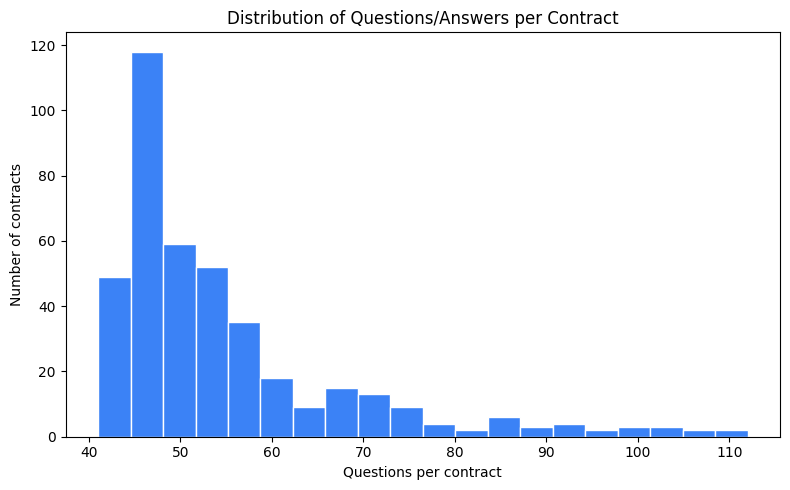

In [282]:

# is title just an id proxy, or does it carry info beyond row count per contract?
print(df.groupby('title').size().describe())
print(df.groupby('title').size().median())

qas_per_title = df.groupby('title').size()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(qas_per_title.values, bins=20, color='#3b82f6', edgecolor='white')
ax.set_xlabel('Questions per contract')
ax.set_ylabel('Number of contracts')
ax.set_title('Distribution of Questions/Answers per Contract')
plt.tight_layout()
plt.show()

The distribution of question/answers per contract is right-skewed, with a mean of 55 qas, and a median of 50. 

category
Document Name                         0.000000
Parties                               0.000497
Agreement Date                        0.074879
Governing Law                         0.126168
Expiration Date                       0.159737
Anti-Assignment                       0.170144
Effective Date                        0.195122
License Grant                         0.240237
Cap On Liability                      0.242134
Audit Rights                          0.301299
Insurance                             0.382148
Post-Termination Services             0.409310
Exclusivity                           0.440135
Minimum Commitment                    0.450082
Revenue/Profit Sharing                0.455592
Rofr/Rofo/Rofn                        0.532081
Non-Transferable License              0.533821
Ip Ownership Assignment               0.544326
Termination For Convenience           0.553377
Renewal Term                          0.590389
Non-Compete                           0.609375
Chan

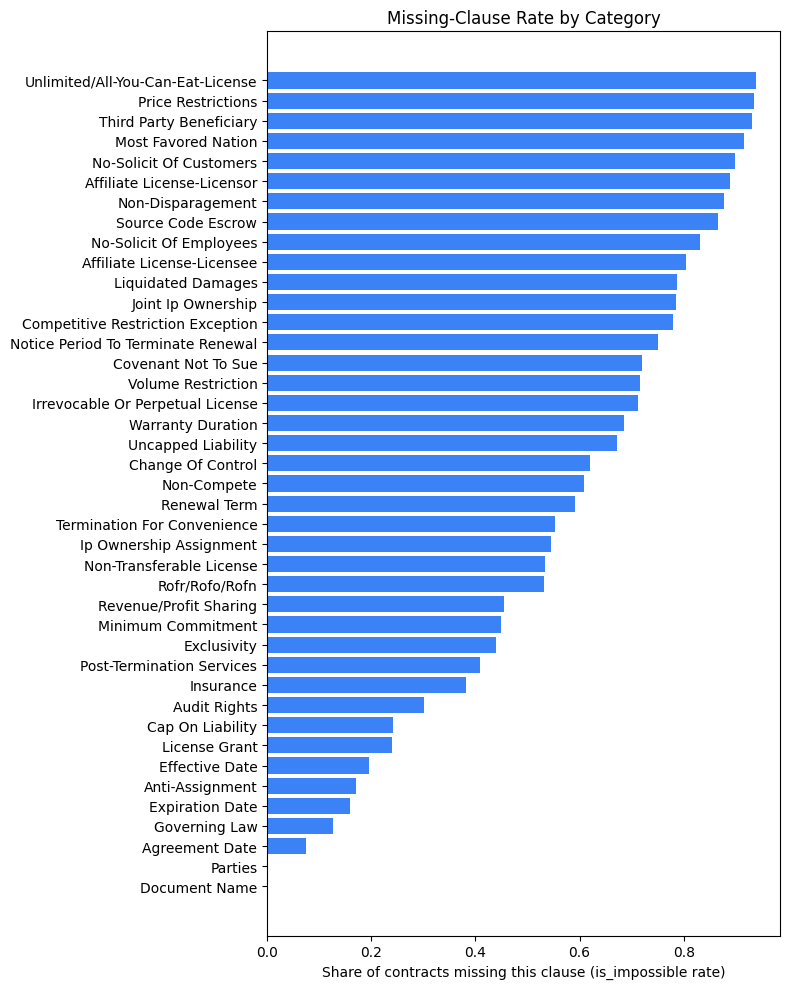

In [283]:
# does is_impossible relate to category (i.e. is a clause type just missing more often in some contracts)?
print(df.groupby('category')['is_impossible'].mean().sort_values())

impossible_rate = df.groupby('category')['is_impossible'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(impossible_rate.index, impossible_rate.values, color='#3b82f6')
ax.set_xlabel('Share of contracts missing this clause (is_impossible rate)')
ax.set_title('Missing-Clause Rate by Category')
plt.tight_layout()
plt.show()


Document Name category questions were never impossible, given that the dataset always includes the name of the document. Parties, the most common question type, had a near-zero rate of impossible clauses.

In [284]:

# does answer length / presence vary meaningfully by category (worth quantifying)?
df['has_answer'] = df['answer_text'].notna()
df['answer_len'] = df['answer_text'].str.len()
df.head()

,answers,id,question,is_impossible,title,category,category_Affiliate License-Licensee,category_Affiliate License-Licensor,category_Agreement Date,category_Anti-Assignment,...,category_Third Party Beneficiary,category_Uncapped Liability,category_Unlimited/All-You-Can-Eat-License,category_Volume Restriction,category_Warranty Duration,answer_text,answer_start,is_impossible_bin,has_answer,answer_len
0,"[{'text': 'DISTRIBUTOR AGREEMENT', 'answer_sta...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,0,0,0,0,...,0,0,0,0,0,DISTRIBUTOR AGREEMENT,44.0,0,True,21.0
1,"[{'text': 'Distributor', 'answer_start': 244}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,Distributor,244.0,0,True,11.0
2,"[{'text': 'Electric City of Illinois L.L.C.', ...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,Electric City of Illinois L.L.C.,49574.0,0,True,32.0
3,"[{'text': 'Electric City of Illinois LLC', 'an...",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,Electric City of Illinois LLC,212.0,0,True,29.0
4,"[{'text': 'Company', 'answer_start': 197}]",LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Highlight the parts (if any) of this contract ...,False,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,0,0,0,0,...,0,0,0,0,0,Company,197.0,0,True,7.0


## Selecting 10 Core Categories

Per the challenge project overview, we need to narrow the 41 categories down to 10 core categories to focus on. Beyond raw frequency and low impossibility rate, we consider:

- **Class balance**: absolute number of *answered* (non-impossible) examples per category, since that's what actually drives usable train/test examples — a category can have a low impossibility rate but still few positives if it's rare overall.
- **Label quality/consistency**: coefficient of variation (std/mean) of `answer_text` length. A high CV suggests annotators captured wildly different granularities under the same category (e.g. sometimes a single date, sometimes a whole clause), which is noisier to model and evaluate.
- **Span extraction difficulty**: median word count of `answer_text`. Very short spans (names, dates) are close to trivial extraction; very long spans are harder to extract cleanly. Mid-length spans (roughly 30-60 words) are the most representative of real "clause review."
- **Redundancy**: several categories cluster around the same legal concept (e.g. Exclusivity / Non-Compete / Competitive Restriction Exception, or Cap On Liability / Uncapped Liability, or the License Grant / Non-Transferable License / Affiliate License family). We prefer one strong representative per cluster rather than several near-duplicates.

In [ ]:
df['num_words'] = df['answer_text'].str.split().str.len()

category_stats = df.groupby('category').agg(
    n_answered=('has_answer', 'sum'),
    impossible_rate=('is_impossible', 'mean'),
    words_median=('num_words', 'median'),
    len_mean=('answer_len', 'mean'),
    len_std=('answer_len', 'std'),
).sort_values('n_answered', ascending=False)

category_stats['len_cv'] = category_stats['len_std'] / category_stats['len_mean']
category_stats.round(2)

,n_answered,impossible_rate,words_median,len_mean,len_std,len_cv
category,,,,,,
Parties,2011,0.00,2.0,22.77,23.82,1.05
License Grant,642,0.24,53.0,431.48,312.68,0.72
Cap On Liability,554,0.24,49.0,379.85,254.17,0.67
Audit Rights,538,0.30,40.0,308.71,218.17,0.71
Anti-Assignment,517,0.17,35.0,299.57,245.22,0.82
Insurance,443,0.38,38.0,325.08,287.72,0.89
Document Name,419,0.00,3.0,29.64,18.12,0.61
Expiration Date,384,0.16,31.0,232.32,157.39,0.68
Agreement Date,383,0.07,3.0,18.39,10.63,0.58


### Reading the table

- **Class balance**: `Parties` through `Rofr/Rofo/Rofn` (n_answered >= ~300) are all healthy. Below ~150-200 positives, train/test splits get thin — this rules out most of the long tail (No-Solicit categories, Non-Disparagement, Most Favored Nation, Third Party Beneficiary, Price Restrictions, Unlimited License, etc.), all under 100 positives.
- **Label consistency (`len_cv`)**: watch out even among frequent categories — `Effective Date` (~1.5) and `Minimum Commitment` (~1.0) have unusually inconsistent span lengths for their type, suggesting inconsistent annotation granularity. `Governing Law`, `Uncapped Liability`, and `Notice Period To Terminate Renewal` are the most consistent (lowest CV).
- **Span difficulty (`words_median`)**: `Parties`, `Document Name`, `Agreement Date`, `Effective Date` are trivially short (2-4 words) — easy but not very representative of "clause review." `License Grant`, `Cap On Liability`, `Audit Rights`, `Post-Termination Services` sit in a 40-60 word sweet spot: meaty clauses, harder extraction, but still learnable (unlike 80-word-median outliers like the Affiliate License categories, which fail the balance cut anyway).
- **Redundancy**: among the viable candidates, avoid picking more than one from the same cluster — `Exclusivity` / `Non-Compete` / `Competitive Restriction Exception` (restraint-of-trade), `Cap On Liability` / `Uncapped Liability` (opposite framings of the same concept), and the license family (`License Grant` / `Non-Transferable License` / `Affiliate License-*`).

### Proposed 10 core categories

1. Parties
2. Document Name
3. Agreement Date
4. Governing Law
5. Expiration Date
6. Anti-Assignment
7. License Grant *(best single representative of the license cluster)*
8. Cap On Liability *(best single representative of the liability cluster)*
9. Audit Rights
10. Exclusivity *(best single representative of the competitive-restraint cluster)* — alternatively, Post-Termination Services trades a higher impossibility rate (~0.41) for a meatier, more clause-like extraction task.